In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [ ]:


# Load and prepare data
df = pd.read_csv('/home/qa/runtime/data/analysis_out/garch/reliance.csv', parse_dates=['Date'], index_col='Date').sort_index()
close_series = df['Close']

# Set rolling window parameters
window_size = 200
test_size = len(close_series) - window_size

# Initialize predictions array and error tracking
predictions = []
actuals = []
history = close_series.iloc[:window_size].copy()

# Walk-forward validation with strict window maintenance
for t in range(test_size):
    # Convert to returns for stationarity
    train_returns = np.log(history).diff().dropna()
    
    # Find optimal ARIMA parameters for current window
    model = auto_arima(train_returns, seasonal=False, 
                      suppress_warnings=True,
                      stepwise=True,
                      error_action='ignore',
                      max_p=5, max_q=5, max_d=1)
    p, d, q = model.order
    
    # Fit model on current window's returns
    arima_model = SARIMAX(train_returns, order=(p, 0, q), trend='c')
    model_fit = arima_model.fit(disp=0)
    
    # Forecast next return
    return_forecast = model_fit.get_forecast(steps=1).predicted_mean.iloc[0]
    
    # Convert return forecast to price prediction
    last_price = history.iloc[-1]
    price_forecast = last_price * np.exp(return_forecast)
    
    # Store predictions and actuals
    predictions.append(price_forecast)
    actual = close_series.iloc[window_size + t]
    actuals.append(actual)
    
    # Update history with actual price and maintain window size
    history = pd.concat([history.iloc[1:], pd.Series(actual, index=[close_series.index[window_size + t]])])

# Convert to numpy arrays for metrics calculation
predictions = np.array(predictions)
actuals = np.array(actuals)

# Calculate metrics
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
r2 = r2_score(actuals, predictions)
errors = actuals - predictions

# Plot results
plt.figure(figsize=(14, 10))

# Price comparison plot
plt.subplot(2, 1, 1)
plt.plot(close_series.index[window_size:], actuals, label='Actual Price', color='blue')
plt.plot(close_series.index[window_size:], predictions, label='ARIMA Predictions', alpha=0.7, color='orange')
plt.title(f'Reliance Closing Price Prediction (Rolling ARIMA {p},{d},{q})')
plt.ylabel('Price (₹)')
plt.legend()

# Error plot
plt.subplot(2, 1, 2)
plt.bar(close_series.index[window_size:], errors, width=1, label='Prediction Error', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title('Prediction Errors')
plt.ylabel('Error (₹)')
plt.xlabel('Date')

plt.tight_layout()
plt.show()

# Print metrics and recent predictions
print(f'''Model Performance Metrics:
MAE: ₹{mae:.2f}
RMSE: ₹{rmse:.2f}
R²: {r2:.4f}
Last 5 Predictions vs Actual:
{pd.DataFrame({'Actual': actuals[-5:], 'Predicted': predictions[-5:], 'Error': errors[-5:]})}''')


/home/qa/runtime/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/qa/runtime/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/qa/runtime/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/qa/runtime/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/qa/runtime/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will b

/home/qa/runtime/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/qa/runtime/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/qa/runtime/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/qa/runtime/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/qa/runtime/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will b

KeyboardInterrupt: 

In [8]:
df = pd.DataFrame({'Actual': actuals, 'Predicted': predictions, 'Error': errors})
df.to_csv('/home/qa/runtime/data/analysis_out/garch/arima_predictions.csv', index=False)

ADF p-value for first-order differencing: 0.0000
ADF p-value for log returns: 0.0000


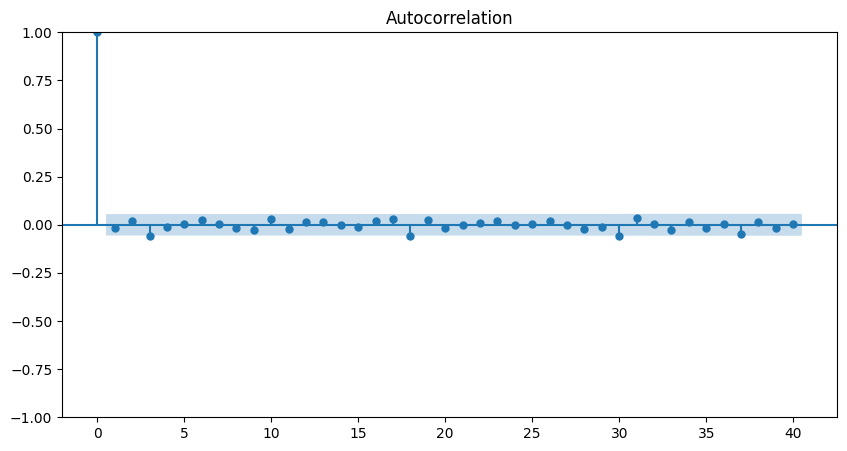

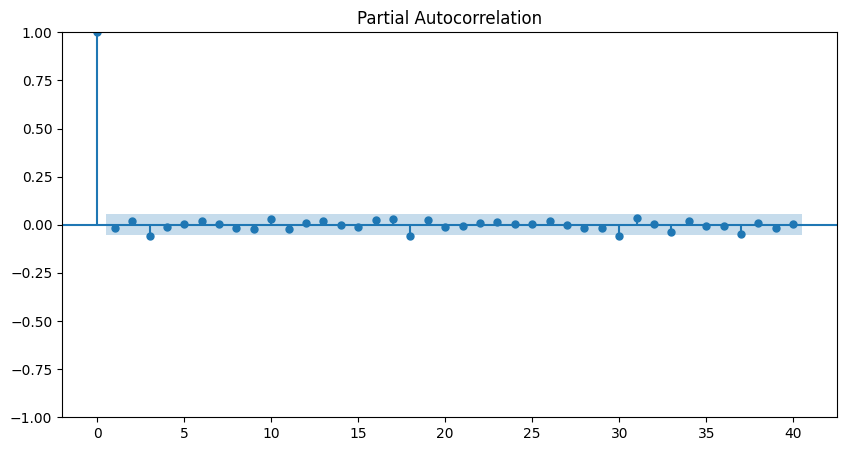

In [2]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv('/home/qa/runtime/data/analysis_out/garch/reliance.csv', parse_dates=['Date'], index_col='Date').sort_index()

# First-order differencing
df['Close_diff'] = df['Close'].diff().dropna()
# Log returns
df['Close_log'] = np.log(df['Close'])
df['Close_log_diff'] = df['Close_log'].diff().dropna()

# ADF Tests
adf_p_value_diff = adfuller(df['Close_diff'].dropna())[1]
adf_p_value_log_diff = adfuller(df['Close_log_diff'].dropna())[1]
print(f'ADF p-value for first-order differencing: {adf_p_value_diff:.4f}')
print(f'ADF p-value for log returns: {adf_p_value_log_diff:.4f}')


# Assume df['Close'] is your stock price series
returns = df['Close'].diff().dropna()  # First differencing
fig, ax = plt.subplots(figsize=(10, 5))
sm.graphics.tsa.plot_acf(returns, lags=40, ax=ax)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sm.graphics.tsa.plot_pacf(returns, lags=40, ax=ax)
plt.show()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load and prepare data
df = pd.read_csv('/home/qa/runtime/data/analysis_out/garch/reliance.csv',
    parse_dates=['Date'], index_col='Date').sort_index()# Set explicit frequency [critical for alignment]

df.index = pd.to_datetime(df.index, utc=True)
del df["Dividends"]
del df["Stock Splits"]

close_series = df['Close']

# Set rolling window parameters
total_samples = len(df)
window_size = 100 # int(total_samples * 0.8)
test_size = total_samples - window_size

# Store predictions and errors
arima_predictions, final_predictions, actuals = [], [], []
history = close_series.iloc[:window_size].copy()
residuals = []
retrain_frequency = 10  # Retrain RF model every 5 steps
model_ml = None

# Walk-forward validation
model_fit = None
for t in range(test_size):
    # Step 1: Compute log returns
    train_returns = np.log(history).diff().dropna()

    # Step 2: Based on ACF , PCF analysis - p =1 and q = 0
    
    if model_fit is None or t % 5 == 0:
        arima_model = SARIMAX(train_returns,
            order=(1, 0, 0),
            seasonal_order=(0, 0, 0, 0),  # No seasonality
            # freq='W-MON',  # Explicit frequency for SARIMAX
            # freq='B', # Business days
            trend='c')
    
        model_fit = arima_model.fit(disp=0)

    # Step 3: Forecast return using ARIMA
    return_forecast = model_fit.get_forecast(steps=1).predicted_mean.iloc[0]

    # Convert return forecast to price
    last_price = history.iloc[-1]
    arima_price_forecast = last_price * np.exp(return_forecast)
    arima_predictions.append(arima_price_forecast)

    # Step 4: Compute residual (forecast error)
    actual = close_series.iloc[window_size + t]
    residual = actual - arima_price_forecast
    residuals.append(residual)
    final_price_forecast = arima_price_forecast


    # Step 5: Train ML Model on past residuals
    # if len(residuals) > 50 and t % retrain_frequency == 0:  # Start ML correction after 50 samples
    #     residual_mean = np.mean(residuals[-50:])
    #     residual_std = np.std(residuals[-50:])
    #     X_train = np.column_stack([
    #         np.array(arima_predictions[-51:-1]),  # t-1 forecast
    #         np.array(residuals[-51:-1]),          # Fixed indices
    #         train_returns.values[-50:],            # Recent returns (volatility)
    #         residual_mean,                         # Mean of past residuals
    #         residual_std                           # Std deviation of past residuals
    #     ])
    #     y_train = np.array(residuals[-51:-1])
        
    #     # Train RF model with optimized parameters
    #     if model_ml is None:
    #         model_ml = RandomForestRegressor(
    #             n_estimators=50,
    #             max_depth=3,
    #             min_samples_leaf=5,
    #             random_state=42
    #         )
    #     model_ml.fit(X_train, y_train)

    #     # Predict correction if RF is trained
    #     if len(residuals) > 50:
    #         X_test = np.array([
    #             arima_price_forecast,
    #             residuals[-1],
    #             residual_mean,  # Mean of past residuals
    #             residual_std    # Standard deviation of past residuals
    #         ]).reshape(1, -1)
    #         correction = model_ml.predict(X_test)[0]
    #         final_price_forecast = arima_price_forecast + correction

    final_predictions.append(final_price_forecast)
    actuals.append(actual)
    # final_predictions.append((close_series.index[window_size + t], final_price_forecast))
    # actuals.append((close_series.index[window_size + t], actual))

    # Update history
    history = pd.concat([history, pd.Series(actual, index=[close_series.index[window_size + t]])]).iloc[-window_size:]

# Convert to numpy arrays
final_predictions, actuals = np.array(final_predictions), np.array(actuals)

# Metrics
mae = mean_absolute_error(actuals, final_predictions)
rmse = np.sqrt(mean_squared_error(actuals, final_predictions))
r2 = r2_score(actuals, final_predictions)
mape = np.mean(np.abs((actuals - final_predictions) / actuals)) * 100
# Directional accuracy
directional_accuracy = np.mean(np.sign(actuals[1:] - actuals[:-1]) == np.sign(final_predictions[1:] - final_predictions[:-1])) * 100
errors = actuals - final_predictions

# Results
print(f"MAE: ₹{mae:.2f}, RMSE: ₹{rmse:.2f}, R²: {r2:.4f}, MAPE: {mape:.2f}%, Directional Accuracy: {directional_accuracy:.2f}%")

# Merge predictions into dataframe
df['Final_Predictions'] = np.nan  # Create empty column
df.iloc[window_size:window_size+len(final_predictions), 
        df.columns.get_loc('Final_Predictions')] = final_predictions

# Save to CSV
df.to_csv('/home/qa/runtime/data/analysis_out/garch/reliance_predictions.csv', index=True)


/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result i

MAE: ₹12.97, RMSE: ₹17.75, R²: 0.9900, MAPE: 1.14%, Directional Accuracy: 51.45%


/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


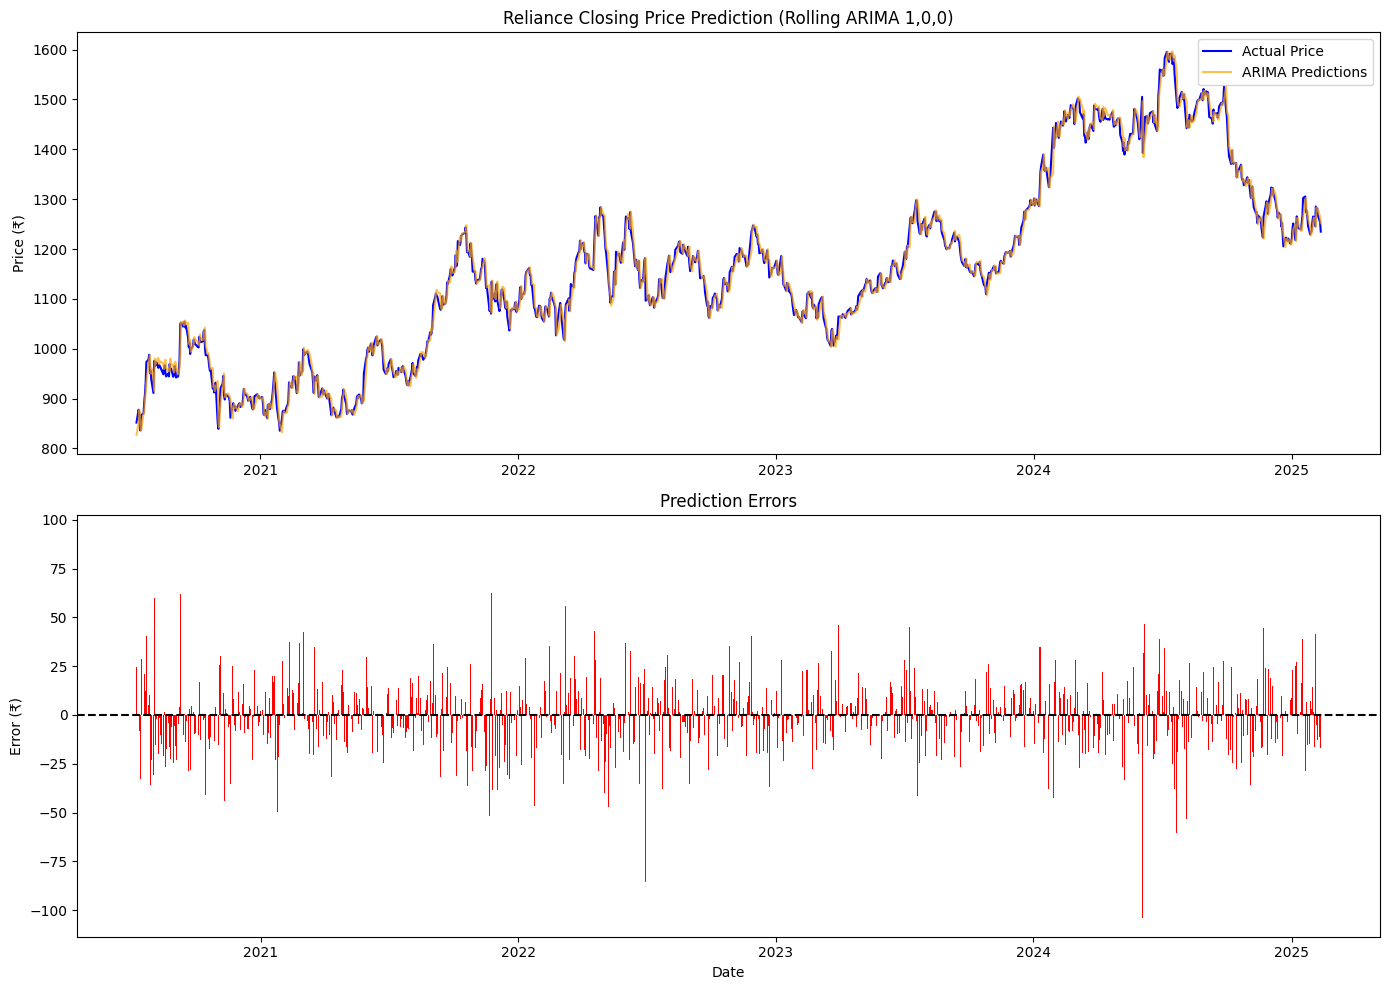

Model Performance Metrics:
MAE: ₹12.97
RMSE: ₹17.75
R²: 0.9900
MAPE: 1.14%
direction_accuracy : 51.45%
Last 5 Predictions vs Actual:
        Actual    Predicted      Error
0  1278.199951  1283.276653  -5.076702
1  1281.550049  1276.287128   5.262920
2  1266.699951  1279.632213 -12.932261
3  1253.650024  1264.804338 -11.154314
4  1234.849976  1251.773941 -16.923965


In [18]:
# Plot results
plt.figure(figsize=(14, 10))

# Price comparison plot
plt.subplot(2, 1, 1)
plt.plot(close_series.index[window_size:], actuals, label='Actual Price', color='blue')
plt.plot(close_series.index[window_size:], final_predictions, label='ARIMA Predictions', alpha=0.7, color='orange')
plt.title(f'Reliance Closing Price Prediction (Rolling ARIMA {1},{0},{0})')
plt.ylabel('Price (₹)')
plt.legend()

# Error plot
plt.subplot(2, 1, 2)
plt.bar(close_series.index[window_size:], errors, width=1, label='Prediction Error', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title('Prediction Errors')
plt.ylabel('Error (₹)')
plt.xlabel('Date')

plt.tight_layout()
plt.show()

# Print metrics and recent predictions
print(f'''Model Performance Metrics:
MAE: ₹{mae:.2f}
RMSE: ₹{rmse:.2f}
R²: {r2:.4f}
MAPE: {mape:.2f}%
direction_accuracy : {directional_accuracy:.2f}%
Last 5 Predictions vs Actual:
{pd.DataFrame({'Actual': actuals[-5:], 'Predicted': final_predictions[-5:], 'Error': errors[-5:]})}''')

Iter 0: Trains on 2015-02-19 18:30:00+00:00 to 2015-12-14 18:30:00+00:00 | Predicts 2015-12-15 18:30:00+00:00
Date: 2015-12-15 18:30:00+00:00, Actual Price: 7750.90, Forecast Price: 7697.84
Iter 1: Trains on 2015-02-22 18:30:00+00:00 to 2015-12-15 18:30:00+00:00 | Predicts 2015-12-16 18:30:00+00:00
Date: 2015-12-16 18:30:00+00:00, Actual Price: 7844.35, Forecast Price: 7747.82
Iter 2: Trains on 2015-02-23 18:30:00+00:00 to 2015-12-16 18:30:00+00:00 | Predicts 2015-12-17 18:30:00+00:00
Date: 2015-12-17 18:30:00+00:00, Actual Price: 7761.95, Forecast Price: 7841.23
Iter 3: Trains on 2015-02-24 18:30:00+00:00 to 2015-12-17 18:30:00+00:00 | Predicts 2015-12-20 18:30:00+00:00
Date: 2015-12-20 18:30:00+00:00, Actual Price: 7834.45, Forecast Price: 7758.87
Iter 4: Trains on 2015-02-25 18:30:00+00:00 to 2015-12-20 18:30:00+00:00 | Predicts 2015-12-21 18:30:00+00:00
Date: 2015-12-21 18:30:00+00:00, Actual Price: 7786.10, Forecast Price: 7831.34
Iter 5: Trains on 2015-02-26 18:30:00+00:00 to 201

/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/qa/runtime/.venv/lib/python3.10/site-packages/arch/univariate/base.py:750: OptimizeWarning: Unknown solver options: gtol
  opt = minimize(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py

Date: 2015-12-22 18:30:00+00:00, Actual Price: 7865.95, Forecast Price: 7779.72
Iter 6: Trains on 2015-03-01 18:30:00+00:00 to 2015-12-22 18:30:00+00:00 | Predicts 2015-12-23 18:30:00+00:00
Date: 2015-12-23 18:30:00+00:00, Actual Price: 7861.05, Forecast Price: 7859.50
Iter 7: Trains on 2015-03-02 18:30:00+00:00 to 2015-12-23 18:30:00+00:00 | Predicts 2015-12-27 18:30:00+00:00
Date: 2015-12-27 18:30:00+00:00, Actual Price: 7925.15, Forecast Price: 7854.60
Iter 8: Trains on 2015-03-03 18:30:00+00:00 to 2015-12-27 18:30:00+00:00 | Predicts 2015-12-28 18:30:00+00:00
Date: 2015-12-28 18:30:00+00:00, Actual Price: 7928.95, Forecast Price: 7918.65
Iter 9: Trains on 2015-03-04 18:30:00+00:00 to 2015-12-28 18:30:00+00:00 | Predicts 2015-12-29 18:30:00+00:00
Date: 2015-12-29 18:30:00+00:00, Actual Price: 7896.25, Forecast Price: 7922.45
Iter 10: Trains on 2015-03-08 18:30:00+00:00 to 2015-12-29 18:30:00+00:00 | Predicts 2015-12-30 18:30:00+00:00
Date: 2015-12-30 18:30:00+00:00, Actual Price: 79

/home/qa/runtime/.venv/lib/python3.10/site-packages/arch/univariate/base.py:750: OptimizeWarning: Unknown solver options: gtol
  opt = minimize(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:

Date: 2016-01-07 18:30:00+00:00, Actual Price: 7601.35, Forecast Price: 7558.05
Iter 16: Trains on 2015-03-16 18:30:00+00:00 to 2016-01-07 18:30:00+00:00 | Predicts 2016-01-10 18:30:00+00:00
Date: 2016-01-10 18:30:00+00:00, Actual Price: 7563.85, Forecast Price: 7591.06
Iter 17: Trains on 2015-03-17 18:30:00+00:00 to 2016-01-10 18:30:00+00:00 | Predicts 2016-01-11 18:30:00+00:00
Date: 2016-01-11 18:30:00+00:00, Actual Price: 7510.30, Forecast Price: 7553.61
Iter 18: Trains on 2015-03-18 18:30:00+00:00 to 2016-01-11 18:30:00+00:00 | Predicts 2016-01-12 18:30:00+00:00
Date: 2016-01-12 18:30:00+00:00, Actual Price: 7562.40, Forecast Price: 7500.13
Iter 19: Trains on 2015-03-19 18:30:00+00:00 to 2016-01-12 18:30:00+00:00 | Predicts 2016-01-13 18:30:00+00:00
Date: 2016-01-13 18:30:00+00:00, Actual Price: 7536.80, Forecast Price: 7552.16
Iter 20: Trains on 2015-03-22 18:30:00+00:00 to 2016-01-13 18:30:00+00:00 | Predicts 2016-01-14 18:30:00+00:00
Date: 2016-01-14 18:30:00+00:00, Actual Price

...

/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in

Date: 2025-01-27 18:30:00+00:00, Actual Price: 22957.25, Forecast Price: 22873.09
Iter 2246: Trains on 2024-04-08 18:30:00+00:00 to 2025-01-27 18:30:00+00:00 | Predicts 2025-01-28 18:30:00+00:00
Date: 2025-01-28 18:30:00+00:00, Actual Price: 23163.10, Forecast Price: 23001.44
Iter 2247: Trains on 2024-04-09 18:30:00+00:00 to 2025-01-28 18:30:00+00:00 | Predicts 2025-01-29 18:30:00+00:00
Date: 2025-01-29 18:30:00+00:00, Actual Price: 23249.50, Forecast Price: 23207.68
Iter 2248: Trains on 2024-04-11 18:30:00+00:00 to 2025-01-29 18:30:00+00:00 | Predicts 2025-01-30 18:30:00+00:00
Date: 2025-01-30 18:30:00+00:00, Actual Price: 23508.40, Forecast Price: 23294.25
Iter 2249: Trains on 2024-04-14 18:30:00+00:00 to 2025-01-30 18:30:00+00:00 | Predicts 2025-02-02 18:30:00+00:00
Date: 2025-02-02 18:30:00+00:00, Actual Price: 23361.05, Forecast Price: 23553.65
Iter 2250: Trains on 2024-04-15 18:30:00+00:00 to 2025-02-02 18:30:00+00:00 | Predicts 2025-02-03 18:30:00+00:00
Date: 2025-02-03 18:30:00

/home/qa/runtime/.venv/lib/python3.10/site-packages/arch/univariate/base.py:750: OptimizeWarning: Unknown solver options: gtol
  opt = minimize(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:

Date: 2025-02-10 18:30:00+00:00, Actual Price: 23071.80, Forecast Price: 23419.30
Iter 2256: Trains on 2024-04-24 18:30:00+00:00 to 2025-02-10 18:30:00+00:00 | Predicts 2025-02-11 18:30:00+00:00
Date: 2025-02-11 18:30:00+00:00, Actual Price: 23045.25, Forecast Price: 23109.00
Iter 2257: Trains on 2024-04-25 18:30:00+00:00 to 2025-02-11 18:30:00+00:00 | Predicts 2025-02-12 18:30:00+00:00
Date: 2025-02-12 18:30:00+00:00, Actual Price: 23031.40, Forecast Price: 23082.41
Iter 2258: Trains on 2024-04-28 18:30:00+00:00 to 2025-02-12 18:30:00+00:00 | Predicts 2025-02-13 18:30:00+00:00
Date: 2025-02-13 18:30:00+00:00, Actual Price: 22929.25, Forecast Price: 23068.54
Iter 2259: Trains on 2024-04-29 18:30:00+00:00 to 2025-02-13 18:30:00+00:00 | Predicts 2025-02-16 18:30:00+00:00
Date: 2025-02-16 18:30:00+00:00, Actual Price: 22959.50, Forecast Price: 22966.22
Iter 2260: Trains on 2024-05-01 18:30:00+00:00 to 2025-02-16 18:30:00+00:00 | Predicts 2025-02-17 18:30:00+00:00
Date: 2025-02-17 18:30:00

/home/qa/runtime/.venv/lib/python3.10/site-packages/arch/univariate/base.py:750: OptimizeWarning: Unknown solver options: gtol
  opt = minimize(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/qa/runtime/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:

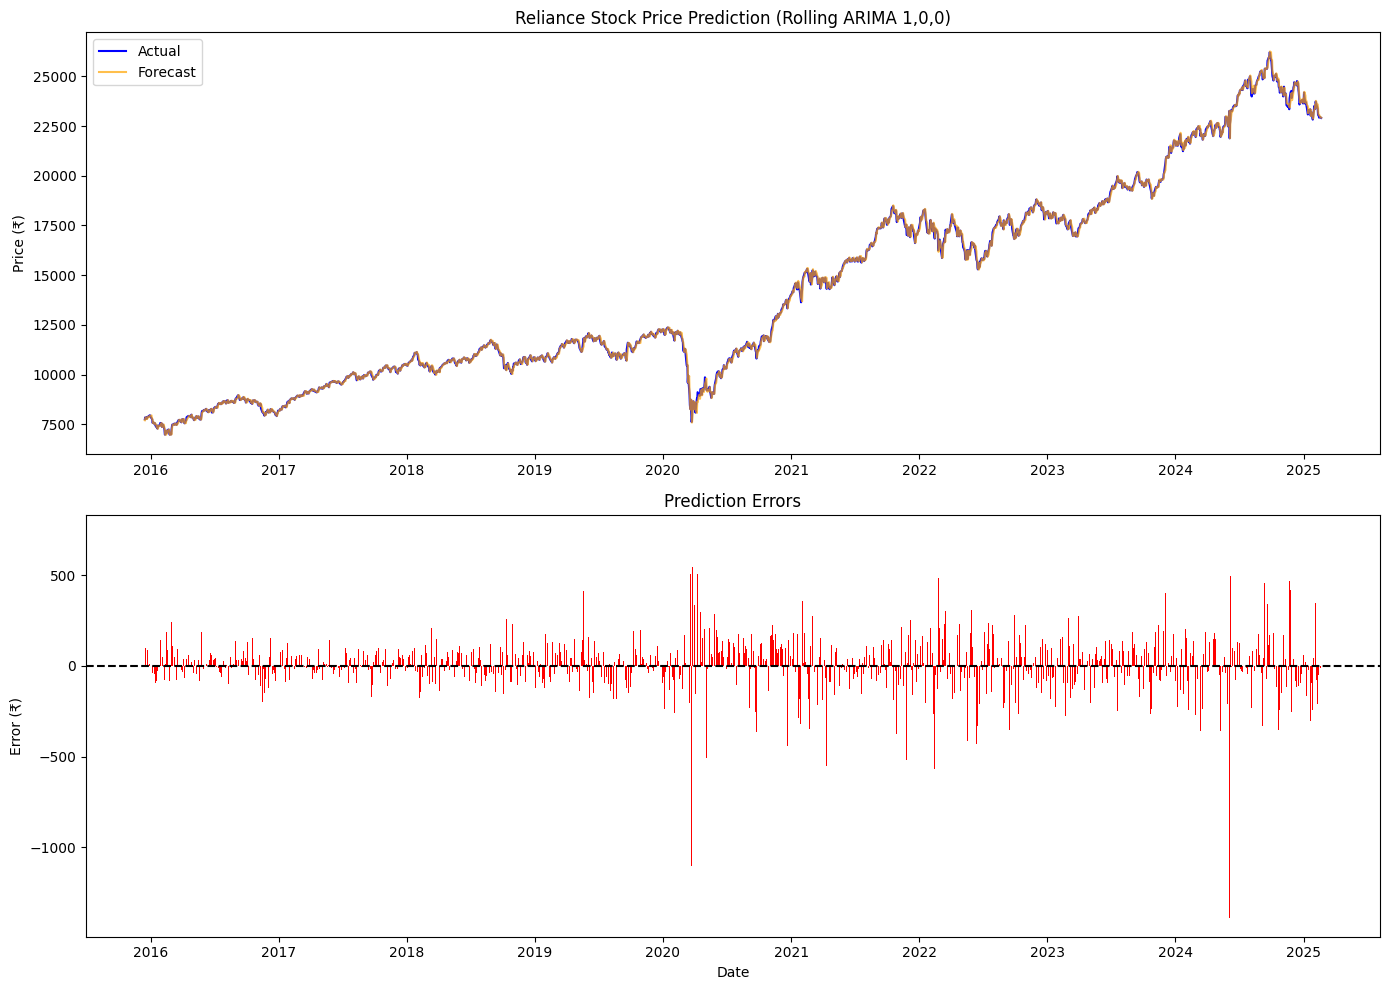

Average Close Price: ₹14202.76
MAE as % of Price: 0.69%
Model Performance Metrics:
MAE: ₹97.49
RMSE: ₹142.40
R²: 0.9992
MAPE: 0.71%
Coverage_95%: 3.49%
Directional Accuracy: 51.02%

Last 5 Predictions:
                                  Close      Forecast       Error
Date                                                             
2025-02-13 18:30:00+00:00  22929.250000  23068.535878 -139.285878
2025-02-16 18:30:00+00:00  22959.500000  22966.220782   -6.720782
2025-02-17 18:30:00+00:00  22945.300781  22956.396038  -11.095257
2025-02-18 18:30:00+00:00  22932.900391  22942.198739   -9.298349
2025-02-19 18:30:00+00:00  22913.150391  22929.800025  -16.649634


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from scipy.stats import t as st
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
import sys

sys.path.append(os.path.dirname(os.path.realpath('__file__')) + '/../../')
from MomentumLearning.StrategyRepos.common_indicators import *

# Load and prepare data
df = pd.read_csv('/home/qa/runtime/data/analysis_out/garch/nifty_1d_10y.csv',
                parse_dates=['Date'], index_col='Date').sort_index()

df.index = pd.to_datetime(df.index, utc=True)
del df["Dividends"]
del df["Stock Splits"]

df['Ref_Price'] = df['Close']
df['Realized_Vol'] = np.log(df['Close']).diff().rolling(5).std() * np.sqrt(252)  # 5-day rolling window

# df = get_kalman_filter_price(df, 'Ref_Price', 0.5, 0.1)

exog_vars = df[['Volume']]  # Example


# Calculate split indices
total_samples = len(df)
train_size = 200  #int(total_samples * 0.8)
test_size = total_samples - train_size

# Initialize forecast column
df['Forecast'] = np.nan
df['Forecast_Volatility'] = np.nan
df['Forecast_Upper'] = np.nan
df['Forecast_Lower'] = np.nan

model_fit = None
garch_result = None

# Rolling window forecasting
for t in range(test_size):
    # Define current training window bounds
    start_idx = t
    end_idx = t + train_size
    test_position = end_idx  # Position we're forecasting
    
    print(f"Iter {t}: Trains on {df.index[start_idx]} to {df.index[end_idx-1]} | Predicts {df.index[test_position]}")
    
    # Get current training data
    train_window = df.iloc[start_idx:end_idx]
    close_prices = train_window['Ref_Price']
    
    # Calculate log returns
    train_returns = np.log(close_prices).diff().dropna()
    
    # Retrain ARIMA every 5 steps or first iteration
    if model_fit is None or t % 5 == 0:
        arima_model = SARIMAX(train_returns,
                            order=(1, 0, 0),
                            seasonal_order=(0, 0, 0, 0),
                            trend='c')
        model_fit = arima_model.fit(disp=0)
        
        # Fit GARCH on ARIMA residuals
        residuals = model_fit.resid * 100
        garch_model = arch_model(residuals, vol='GARCH', p=1, q=1, dist='t', rescale=True)
        # Add parameter constraints (search result [2])
        garch_model.parameter_bounds = [
            (None, None),    # Constant
            (1e-6, None),    # omega
            (0.0, 1.0),      # alpha
            (0.0, 1.0),      # beta
            (2.1, 30.0)      # nu (degrees of freedom > 2)
        ]
        garch_result = garch_model.fit(update_freq=0, disp='off', options={'maxiter': 1000, 'gtol': 1e-04})
        # print(f"Garch Result Summary : {garch_result.summary()}")
    
    # Generate forecast
    return_forecast = model_fit.get_forecast(steps=1).predicted_mean.iloc[0]
    price_forecast = close_prices.iloc[-1] * np.exp(return_forecast)
    
    # GARCH volatility forecast
    garch_forecast = garch_result.forecast(horizon=1, method='simulation')
    vol_forecast = np.sqrt(garch_forecast.variance.iloc[-1,0]) / 100 
    
    # Calculate prediction intervals
    # upper_bound = price_forecast * np.exp(1.96 * vol_forecast)
    # lower_bound = price_forecast * np.exp(-1.96 * vol_forecast)
    dof = garch_result.params['nu']  # Degrees of freedom if using t-errors
    upper_bound = price_forecast * np.exp(st.ppf(0.975, dof) * vol_forecast)
    lower_bound = price_forecast * np.exp(st.ppf(0.025, dof) * vol_forecast)
    
    # Print the actual and forcast price for a day
    print(f'Date: {df.index[test_position]}, Actual Price: {df.iloc[test_position]["Close"]:.2f}, Forecast Price: {price_forecast:.2f}')    
    
    # Update DataFrame directly
    df.iloc[test_position, df.columns.get_loc('Forecast')] = price_forecast
    df.iloc[test_position, df.columns.get_loc('Forecast_Volatility')] = vol_forecast
    df.iloc[test_position, df.columns.get_loc('Forecast_Upper')] = upper_bound
    df.iloc[test_position, df.columns.get_loc('Forecast_Lower')] = lower_bound

# Post-processing
df['Error'] = df['Close'] - df['Forecast']
df['|Error|'] = np.abs(df['Error'])
df['|Erorr|%'] = (df['|Error|'] / df['Close']) * 100

# Save results
df.to_csv('/home/qa/runtime/data/analysis_out/garch/reliance_forecast.csv', index=True)

# Metrics
# Calculate all metrics using DataFrame columns
test_period = df.iloc[train_size:].dropna(subset=['Forecast'])
# delete all rows where '|Erorr|%' >= 2%
# test_period = test_period[test_period['|Erorr|%'] < 2]

actuals = test_period['Close']
predictions = test_period['Forecast']
lower_bounds = test_period['Forecast_Lower']
upper_bounds = test_period['Forecast_Upper']

# Calculate directional accuracy properly
actual_shifts = test_period['Close'].shift(1).iloc[1:]  # Remove first NaN
predicted_deltas = test_period['Forecast'].iloc[1:] - actual_shifts
actual_deltas = test_period['Close'].iloc[1:] - actual_shifts

metrics = {
    'MAE': mean_absolute_error(actuals, predictions),
    'RMSE': np.sqrt(mean_squared_error(actuals, predictions)),
    'R²': r2_score(actuals, predictions),
    'MAPE': (np.abs(test_period['Error']/test_period['Close']).mean()) * 100,
    'Coverage_95%': np.mean((lower_bound < actuals) & (actuals < upper_bound)) * 100,
    'Directional Accuracy': (
        np.mean(np.sign(predicted_deltas) == np.sign(actual_deltas)) * 100
    )
}

# Plotting
plt.figure(figsize=(14, 10))

# Price plot
plt.subplot(2,1,1)
plt.plot(test_period.index, actuals, label='Actual', color='blue')
plt.plot(test_period.index, predictions, label='Forecast', alpha=0.7, color='orange')
plt.title(f'Reliance Stock Price Prediction (Rolling ARIMA {1},{0},{0})')
plt.ylabel('Price (₹)')
plt.legend()

# Error plot
plt.subplot(2,1,2)
plt.bar(test_period.index, test_period['Error'], width=1, color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title('Prediction Errors')
plt.ylabel('Error (₹)')
plt.xlabel('Date')

# Plot GARCH volatility vs Realized Volatility
# plt.subplot(2,1,1)
# plt.plot(test_period.index, test_period['Realized_Vol'], label='Realized Volatility', color='blue', alpha=0.5)
# plt.plot(test_period.index, test_period['Forecast_Volatility'], label='Forecast Volatility', color='orange', alpha=0.7)
# plt.title('Realized vs Forecast Volatility')
# plt.ylabel('Volatility')
# plt.legend()

plt.tight_layout()
plt.show()

print(f"Average Close Price: ₹{actuals.mean():.2f}")
print(f"MAE as % of Price: {(metrics['MAE'] / actuals.mean())*100:.2f}%")

# Print results
print(f'''Model Performance Metrics:
MAE: ₹{metrics["MAE"]:.2f}
RMSE: ₹{metrics["RMSE"]:.2f}
R²: {metrics["R²"]:.4f}
MAPE: {metrics["MAPE"]:.2f}%
Coverage_95%: {metrics["Coverage_95%"]:.2f}%
Directional Accuracy: {metrics["Directional Accuracy"]:.2f}%

Last 5 Predictions:
{test_period[['Close', 'Forecast', 'Error']].tail()}''')
